<!-- portfolio-intro -->
# Портфельный кейс: дисбаланс классов в задаче churn prediction

Этот репозиторий содержит два связанных ноутбука:

- базовое исследование качества модели на дисбалансной выборке;
- вариант с обработкой дисбаланса через SMOTE.

Ноутбуки приведены к портфельному формату: локальные данные ищутся в `data/`, а все выводы и объяснения даны на русском языке.


# Изучение влияния дисбаланса выборки на качество моделей на примере распознания оттока клиентов

<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Подготовка-данных" data-toc-modified-id="Подготовка-данных-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Подготовка данных</a></span><ul class="toc-item"><li><span><a href="#Импорт-необходимых-для-исследования-библиотек" data-toc-modified-id="Импорт-необходимых-для-исследования-библиотек-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Импорт необходимых для исследования библиотек</a></span></li><li><span><a href="#Чтение-данных" data-toc-modified-id="Чтение-данных-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Чтение данных</a></span></li><li><span><a href="#Описание-данных" data-toc-modified-id="Описание-данных-1.3"><span class="toc-item-num">1.3&nbsp;&nbsp;</span>Описание данных</a></span></li><li><span><a href="#Изучение-общей-информации-о-данных" data-toc-modified-id="Изучение-общей-информации-о-данных-1.4"><span class="toc-item-num">1.4&nbsp;&nbsp;</span>Изучение общей информации о данных</a></span></li><li><span><a href="#Предобработка-данных.-Исключение-неинформативных-признаков,-проверка-на-мультиколлинеарность" data-toc-modified-id="Предобработка-данных.-Исключение-неинформативных-признаков,-проверка-на-мультиколлинеарность-1.5"><span class="toc-item-num">1.5&nbsp;&nbsp;</span>Предобработка данных. Исключение неинформативных признаков, проверка на мультиколлинеарность</a></span></li><li><span><a href="#Исследование-числовых-признаков" data-toc-modified-id="Исследование-числовых-признаков-1.6"><span class="toc-item-num">1.6&nbsp;&nbsp;</span>Исследование числовых признаков</a></span></li><li><span><a href="#Исследование-номинативных-признаков.-Кодировка-данных" data-toc-modified-id="Исследование-номинативных-признаков.-Кодировка-данных-1.7"><span class="toc-item-num">1.7&nbsp;&nbsp;</span>Исследование номинативных признаков. Кодировка данных</a></span></li><li><span><a href="#Сплит-данных.-Масштабирование-чиловых-признаков" data-toc-modified-id="Сплит-данных.-Масштабирование-чиловых-признаков-1.8"><span class="toc-item-num">1.8&nbsp;&nbsp;</span>Сплит данных. Масштабирование чиловых признаков</a></span></li></ul></li><li><span><a href="#Исследование-задачи" data-toc-modified-id="Исследование-задачи-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Исследование задачи</a></span><ul class="toc-item"><li><span><a href="#Анализ-баланса-целевого-класса" data-toc-modified-id="Анализ-баланса-целевого-класса-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Анализ баланса целевого класса</a></span></li><li><span><a href="#Функция-для-исследования-задачи.-Описание-F1-и-AUC-ROC-метрик" data-toc-modified-id="Функция-для-исследования-задачи.-Описание-F1-и-AUC-ROC-метрик-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Функция для исследования задачи. Описание F1 и AUC-ROC метрик</a></span></li><li><span><a href="#Логистическая-регрессия" data-toc-modified-id="Логистическая-регрессия-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>Логистическая регрессия</a></span></li><li><span><a href="#Дерево-решений" data-toc-modified-id="Дерево-решений-2.4"><span class="toc-item-num">2.4&nbsp;&nbsp;</span>Дерево решений</a></span><ul class="toc-item"><li><span><a href="#Гиперпараметры-по-умолчанию" data-toc-modified-id="Гиперпараметры-по-умолчанию-2.4.1"><span class="toc-item-num">2.4.1&nbsp;&nbsp;</span>Гиперпараметры по умолчанию</a></span></li><li><span><a href="#Подбор-гиперпараметров" data-toc-modified-id="Подбор-гиперпараметров-2.4.2"><span class="toc-item-num">2.4.2&nbsp;&nbsp;</span>Подбор гиперпараметров</a></span></li><li><span><a href="#Оптимальные-параметры" data-toc-modified-id="Оптимальные-параметры-2.4.3"><span class="toc-item-num">2.4.3&nbsp;&nbsp;</span>Оптимальные параметры</a></span></li></ul></li><li><span><a href="#Случайный-лес" data-toc-modified-id="Случайный-лес-2.5"><span class="toc-item-num">2.5&nbsp;&nbsp;</span>Случайный лес</a></span><ul class="toc-item"><li><span><a href="#Гиперпараметры-по-умолчанию" data-toc-modified-id="Гиперпараметры-по-умолчанию-2.5.1"><span class="toc-item-num">2.5.1&nbsp;&nbsp;</span>Гиперпараметры по умолчанию</a></span></li><li><span><a href="#Подбор-гиперпараметров" data-toc-modified-id="Подбор-гиперпараметров-2.5.2"><span class="toc-item-num">2.5.2&nbsp;&nbsp;</span>Подбор гиперпараметров</a></span></li><li><span><a href="#Оптимальные-гиперпараметры" data-toc-modified-id="Оптимальные-гиперпараметры-2.5.3"><span class="toc-item-num">2.5.3&nbsp;&nbsp;</span>Оптимальные гиперпараметры</a></span></li></ul></li></ul></li><li><span><a href="#Борьба-с-дисбалансом" data-toc-modified-id="Борьба-с-дисбалансом-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Борьба с дисбалансом</a></span><ul class="toc-item"><li><span><a href="#Увеличение-выборки" data-toc-modified-id="Увеличение-выборки-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Увеличение выборки</a></span></li><li><span><a href="#Уменьшение-выборки" data-toc-modified-id="Уменьшение-выборки-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Уменьшение выборки</a></span></li><li><span><a href="#Функция-для-исследования-задачи-на-увеличенной-выборке" data-toc-modified-id="Функция-для-исследования-задачи-на-увеличенной-выборке-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Функция для исследования задачи на увеличенной выборке</a></span></li><li><span><a href="#Функция-для-исследования-задачи-на-уменьшенной-выборке" data-toc-modified-id="Функция-для-исследования-задачи-на-уменьшенной-выборке-3.4"><span class="toc-item-num">3.4&nbsp;&nbsp;</span>Функция для исследования задачи на уменьшенной выборке</a></span></li><li><span><a href="#Логистическая-регрессия" data-toc-modified-id="Логистическая-регрессия-3.5"><span class="toc-item-num">3.5&nbsp;&nbsp;</span>Логистическая регрессия</a></span><ul class="toc-item"><li><span><a href="#Взвешивание-класса" data-toc-modified-id="Взвешивание-класса-3.5.1"><span class="toc-item-num">3.5.1&nbsp;&nbsp;</span>Взвешивание класса</a></span></li><li><span><a href="#Upsampling" data-toc-modified-id="Upsampling-3.5.2"><span class="toc-item-num">3.5.2&nbsp;&nbsp;</span>Upsampling</a></span></li><li><span><a href="#Downsampling" data-toc-modified-id="Downsampling-3.5.3"><span class="toc-item-num">3.5.3&nbsp;&nbsp;</span>Downsampling</a></span></li></ul></li><li><span><a href="#Дерево-решений" data-toc-modified-id="Дерево-решений-3.6"><span class="toc-item-num">3.6&nbsp;&nbsp;</span>Дерево решений</a></span><ul class="toc-item"><li><span><a href="#Взвешивание-классов" data-toc-modified-id="Взвешивание-классов-3.6.1"><span class="toc-item-num">3.6.1&nbsp;&nbsp;</span>Взвешивание классов</a></span></li><li><span><a href="#Upsampling" data-toc-modified-id="Upsampling-3.6.2"><span class="toc-item-num">3.6.2&nbsp;&nbsp;</span>Upsampling</a></span></li><li><span><a href="#Downsampling" data-toc-modified-id="Downsampling-3.6.3"><span class="toc-item-num">3.6.3&nbsp;&nbsp;</span>Downsampling</a></span></li></ul></li><li><span><a href="#Случайный-лес" data-toc-modified-id="Случайный-лес-3.7"><span class="toc-item-num">3.7&nbsp;&nbsp;</span>Случайный лес</a></span><ul class="toc-item"><li><span><a href="#Взвешивание-классов" data-toc-modified-id="Взвешивание-классов-3.7.1"><span class="toc-item-num">3.7.1&nbsp;&nbsp;</span>Взвешивание классов</a></span></li><li><span><a href="#Upsampling" data-toc-modified-id="Upsampling-3.7.2"><span class="toc-item-num">3.7.2&nbsp;&nbsp;</span>Upsampling</a></span></li><li><span><a href="#Downsampling" data-toc-modified-id="Downsampling-3.7.3"><span class="toc-item-num">3.7.3&nbsp;&nbsp;</span>Downsampling</a></span></li></ul></li><li><span><a href="#Summary-по-экспериметам-с-балансирвоание-выборки" data-toc-modified-id="Summary-по-экспериметам-с-балансирвоание-выборки-3.8"><span class="toc-item-num">3.8&nbsp;&nbsp;</span>Summary по экспериметам с балансирвоание выборки</a></span><ul class="toc-item"><li><span><a href="#Логистическая-регрессия" data-toc-modified-id="Логистическая-регрессия-3.8.1"><span class="toc-item-num">3.8.1&nbsp;&nbsp;</span>Логистическая регрессия</a></span></li><li><span><a href="#Решающее-дерево" data-toc-modified-id="Решающее-дерево-3.8.2"><span class="toc-item-num">3.8.2&nbsp;&nbsp;</span>Решающее дерево</a></span></li><li><span><a href="#Случайный-лес" data-toc-modified-id="Случайный-лес-3.8.3"><span class="toc-item-num">3.8.3&nbsp;&nbsp;</span>Случайный лес</a></span></li></ul></li></ul></li><li><span><a href="#Тестирование-модели" data-toc-modified-id="Тестирование-модели-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Тестирование модели</a></span><ul class="toc-item"><li><span><a href="#Проверка-модели-на-адекватность" data-toc-modified-id="Проверка-модели-на-адекватность-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Проверка модели на адекватность</a></span></li><li><span><a href="#Проверка-обощающей-возможности-модели" data-toc-modified-id="Проверка-обощающей-возможности-модели-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Проверка обощающей возможности модели</a></span></li></ul></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Вывод</a></span></li></ul></div>

# Фабула

Из «Бета-Банка» стали уходить клиенты. Каждый месяц. Немного, но заметно. Банковские маркетологи посчитали: сохранять текущих клиентов дешевле, чем привлекать новых.

Необходимо спрогнозировать, уйдёт клиент из банка в ближайшее время или нет. Для анализа предоставлены исторические данные о поведении клиентов и расторжении договоров с банком. 

Требуеться построить модель с предельно большим значением *F1*-меры, но не менее 0.59.

Дополнительно измерить *AUC-ROC*, сравнивайте её значение с *F1*-мерой.

Источник данных: [https://www.kaggle.com/barelydedicated/bank-customer-churn-modeling](https://www.kaggle.com/barelydedicated/bank-customer-churn-modeling)

## Подготовка данных
### Импорт необходимых для исследования библиотек

In [56]:
# импорт библиотек для анализа и экспериментов
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import pandas as pd
pd.options.mode.chained_assignment = None

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context(context='notebook')
sns.set_style(style='whitegrid')
sns.set_palette('Blues')

import numpy as np

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.utils import shuffle

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

from imblearn.over_sampling import SMOTE

from sklearn.metrics import f1_score, roc_auc_score, precision_recall_curve, roc_curve

### Чтение данных

In [ ]:
# чтение представленного файла
from pathlib import Path

candidate_paths = [
    Path('data/churn.csv'),
    Path('/content/churn.csv'),
    Path('/content/сhurn.csv'),
    Path('/datasets/Churn.csv'),
]

for dataset_path in candidate_paths:
    if dataset_path.exists():
        break
else:
    raise FileNotFoundError('Не найден churn.csv ни в локальной папке data, ни в старых учебных путях.')

df = pd.read_csv(dataset_path)

# отображение данных, размера матрицы
display(df.head())
df.shape


Данные прочитались корректно. 10 000 строк (наблюдений), 14 колонок (признаков наблюдений).

### Описание данных

**Признаки**

- RowNumber — индекс строки в данных
- CustomerId — уникальный идентификатор клиента
- Surname — фамилия
- CreditScore — кредитный рейтинг
- Geography — страна проживания
- Gender — пол
- Age — возраст
- Tenure — сколько лет человек является клиентом банка
- Balance — баланс на счёте
- NumOfProducts — количество продуктов банка, используемых клиентом
- HasCrCard — наличие кредитной карты
- IsActiveMember — активность клиента
- EstimatedSalary — предполагаемая зарплата

**Целевой признак**

- Exited — факт ухода клиента

### Изучение общей информации о данных

In [7]:
# пропущенные значения
pd.DataFrame({'NaN_count': df.isna().sum(), 
              'NaN_share': df.isna().mean(),
             'data_type': df.dtypes})

,NaN_count,NaN_share,data_type
RowNumber,0,0.0000,int64
CustomerId,0,0.0000,int64
Surname,0,0.0000,object
CreditScore,0,0.0000,int64
Geography,0,0.0000,object
Gender,0,0.0000,object
Age,0,0.0000,int64
Tenure,909,0.0909,float64
Balance,0,0.0000,float64
NumOfProducts,0,0.0000,int64


Признак - период взаимодействия клиента с банком, имеет 9% пропущенных значений.

Изучим распределение признака, для принятия решения о предобработке пропусков.

### Предобработка данных. Исключение неинформативных признаков, проверка на мультиколлинеарность

,Tenure
count,9091.000000
mean,4.997690
std,2.894723
min,0.000000
25%,2.000000
50%,5.000000
75%,7.000000
max,10.000000


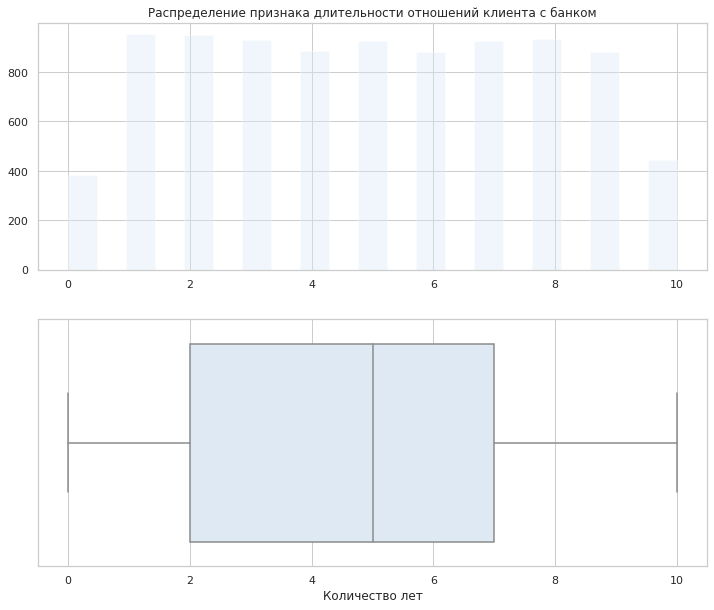

In [8]:
# визуализация распределения признака, с пропущенными значениями
display(df[['Tenure']].describe())

plt.figure(figsize=(12,10))
plt.subplot(2, 1, 1)
sns.distplot(df['Tenure'], kde=False)
plt.title('Распределение признака длительности отношений клиента с банком')
plt.xlabel('')
plt.subplot(2, 1, 2)
sns.boxplot(df['Tenure'])
plt.xlabel('Количество лет')
plt.show()

Признак Tenure распределен практически равномерно. 9091 наблюдения со среднем значением 4,99 лет, медианой в 5 лет и стандарным отклонение в 2.89 лет. Рефертное значение +/- 5,78 лет.

Выбросы и экстренумы не выявлены.

Проведем замену пропущенных значений на средние значения с группировкой по следующим переменным: кредитный рейтинг, локация, пол и возраст, исходя из предпосылки, что пользователи со сходими признаками в среднем явлются клиентами банка схоего периода.

In [9]:
# замена пропущенных значений группировкой по нескольким признакам
df['Tenure'] = (
    df['Tenure']
    .fillna(
        df.groupby(['CreditScore', 'Geography', 'Gender', 'Age'])
        ['Tenure'].transform('mean'))
)

In [10]:
# пропущенные значение после предобработки
pd.DataFrame({'NaN_count': df.isna().sum(), 
              'NaN_share': df.isna().mean(),
             'data_type': df.dtypes})

,NaN_count,NaN_share,data_type
RowNumber,0,0.0000,int64
CustomerId,0,0.0000,int64
Surname,0,0.0000,object
CreditScore,0,0.0000,int64
Geography,0,0.0000,object
Gender,0,0.0000,object
Age,0,0.0000,int64
Tenure,763,0.0763,float64
Balance,0,0.0000,float64
NumOfProducts,0,0.0000,int64


Снизили количество пропущенных значений в признаке до 7,6%. 

Полностью исключить пропуски не удалось - в представленных на анализ данных не достаточно сведений о клиентах схожего пола, возраст, географии и кредитного скора.

Проанализируем, как изменилось распределение признака, после провденных замен.

,Tenure
count,9237.000000
mean,4.992151
std,2.891768
min,0.000000
25%,2.000000
50%,5.000000
75%,7.000000
max,10.000000


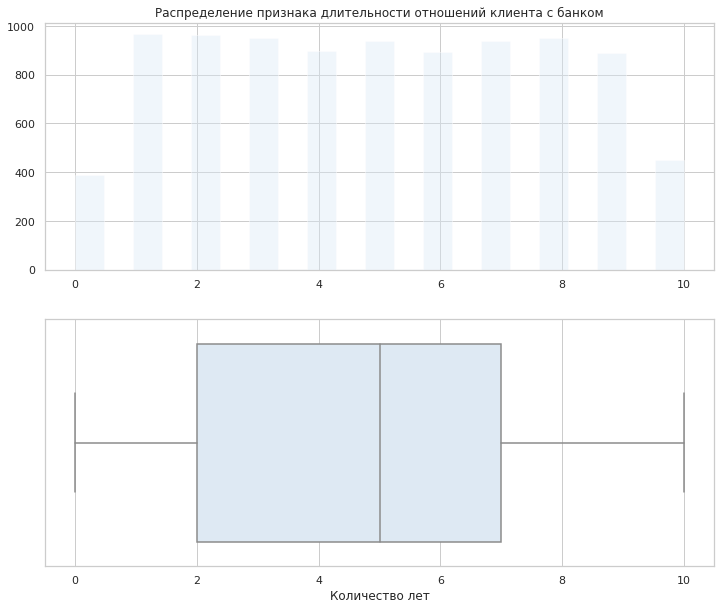

In [11]:
# визуализация распределения признака, после предобработки пропущенных значений
display(df[['Tenure']].describe())

plt.figure(figsize=(12,10))
plt.subplot(2, 1, 1)
sns.distplot(df['Tenure'], kde=False)
plt.title('Распределение признака длительности отношений клиента с банком')
plt.xlabel('')
plt.subplot(2, 1, 2)
sns.boxplot(df['Tenure'])
plt.xlabel('Количество лет')
plt.show()

Среднее значение, медиана и стандратное отклонение не изменились. Распределение осталось прежним. Замена пропущенных значений произведена корреткно.

Дальнейшие пропуски обработаем методом К-ближайших соседей. При этом выделим только числовые признаки для обучения модели, откажемся от приведения признаков к единой размерности, но исключим неинформативные признаки и проверим данные на колиниарность.

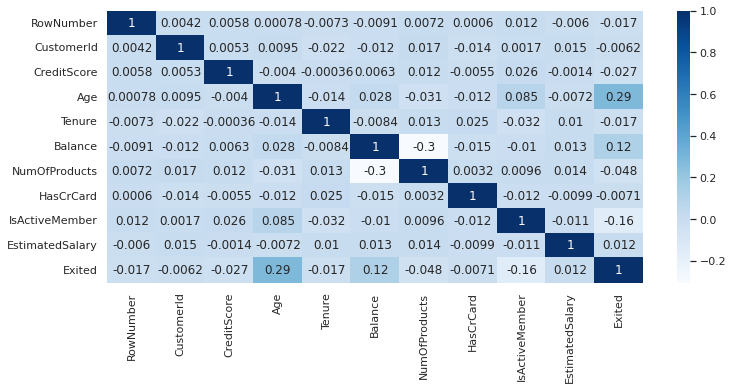

In [12]:
# определение линейной зависимости в данных
plt.figure(figsize=(12, 5))
sns.heatmap(df.corr(), annot=True, cmap='Blues')
plt.show()

Целевая переменная прямо коррелирует с возрастом клиента и балансом счета: чем старше клиент (до определенного возраста) и чем выше баланс счета, тем менее вероятность расторгнуть договор банковского счета. Однако, связь довольно слабая.

Обратная зависимость наблюдается между кредитным рейтингом, активностью клиента и длительностью отношений с банков: чем выше скоринг клиента, чем клиент активнее пользуется услугами банка и чем длительнее отношения клиента с банком, тем меньше шансов потерять такого пользователя. Однако, связь также крайне слаба.

Далее. Представлется неоправданным включение в модель признаков - индекс строки в данных и фамилии клиента. Что касается ID клиента, то несмотря на практическое отсутвие связи с целевой переменной следуют проанализировать порядок присвоения иденификатора клиенту. Например, более ранне клиенты имеют меньший ID-номер.

,first_ID,last_ID
Tenure,,
0.000000,15566467,15815534
1.000000,15565706,15815660
1.500000,15763460,15763460
2.000000,15566494,15815626
2.500000,15657139,15657139
2.666667,15647800,15790744
3.000000,15565878,15815428
3.333333,15718443,15718443
3.666667,15626985,15773934


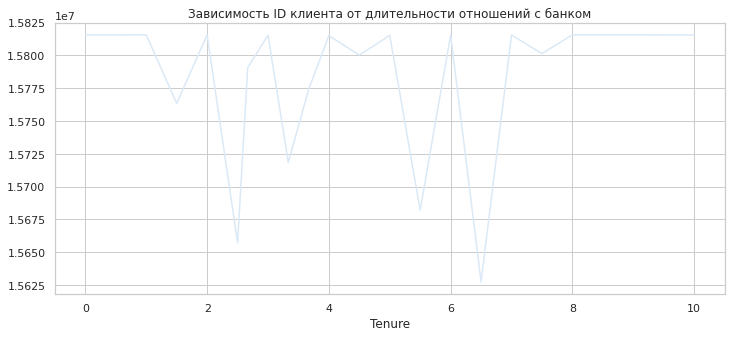

In [13]:
# определение зависимости ID клиента от момента заключение договора с банком
display(df.groupby('Tenure').agg(first_ID = ('CustomerId', 'min'),
                        last_ID = ('CustomerId', 'max')))

# визуализация зависимости ID клиента от длительности отношений с банком
df.groupby('Tenure')['CustomerId'].max().plot(figsize=(12, 5))
plt.title('Зависимость ID клиента от длительности отношений с банком')
plt.show()

Нет. Связь между сроком действия банковского договора и ID не выявлено. 

Таким образом, исключим CustomerId наравне с RowNumber и Surname и перечня признаков для обучения моделей.

In [14]:
# отбор признаков для обучение моделей
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

Рассмотрим взаимодействие оставшихся признаков между собой, с целью детекции возможной коллинеарности.

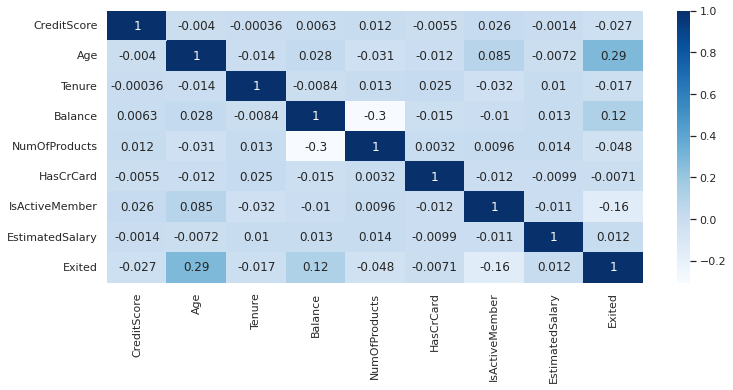

In [15]:
# изучение признаков на предмет коллинеарности
plt.figure(figsize=(12, 5))
sns.heatmap(df.corr(), annot=True, cmap='Blues')
plt.show()

Слабая положительная связь наблюдается между возрастом и активностью клиента, как пользователя банка, которая в силу крайне низкой корреляции - 0,085 не повредит моделям. 

Таким образом, дополнительное исключение признаков не требуется.

Далее проведем замену пропущенных значений методом К-ближайших соседей.

In [16]:
# инициация модели
imputer = KNNImputer()

# обучение и реализация модели
df_numeric = pd.DataFrame(imputer.fit_transform(df.select_dtypes(include=['int64', 'float64'])),
            columns=df.select_dtypes(include=['int64', 'float64']).columns)

# включение признака в общие данные
df = df.drop('Tenure', axis=1).merge(df_numeric)

# приведение типа данных к подабающим
df['Tenure'] = df['Tenure'].astype(int)

In [17]:
# пропущенные значение после предобработки
pd.DataFrame({'NaN_count': df.isna().sum(), 
              'NaN_share': df.isna().mean(),
             'data_type': df.dtypes})

,NaN_count,NaN_share,data_type
CreditScore,0,0.0,int64
Geography,0,0.0,object
Gender,0,0.0,object
Age,0,0.0,int64
Balance,0,0.0,float64
NumOfProducts,0,0.0,int64
HasCrCard,0,0.0,int64
IsActiveMember,0,0.0,int64
EstimatedSalary,0,0.0,float64
Exited,0,0.0,int64


Пропущенные значения отсутсвуют. Узучим распределение признака, после произведения всех замен пропущенных значений.

,Tenure
count,10000.000000
mean,4.962200
std,2.804097
min,0.000000
25%,3.000000
50%,5.000000
75%,7.000000
max,10.000000


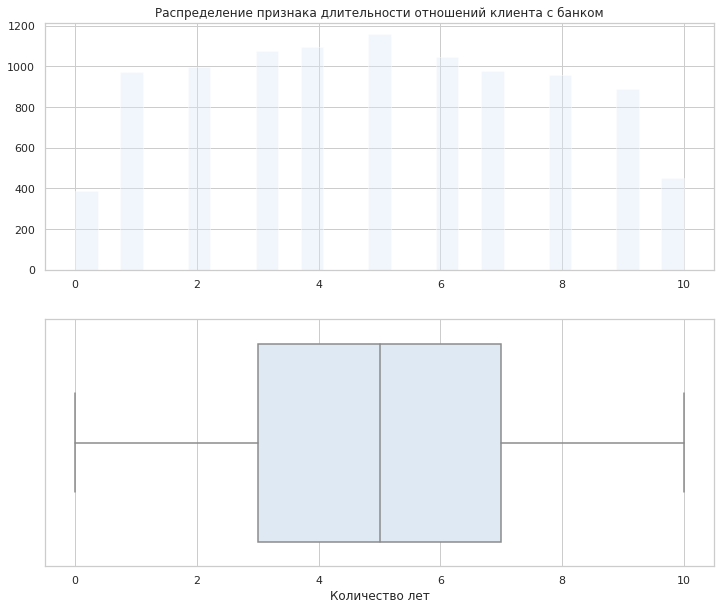

In [18]:
# визуализация распределения признака, после предобработки пропущенных значений
display(df[['Tenure']].describe())

plt.figure(figsize=(12,10))
plt.subplot(2, 1, 1)
sns.distplot(df['Tenure'], kde=False)
plt.title('Распределение признака длительности отношений клиента с банком')
plt.xlabel('')
plt.subplot(2, 1, 2)
sns.boxplot(df['Tenure'])
plt.xlabel('Количество лет')
plt.show()

Медиана осталась неизменной - 5 лет, среднее значение приблизилось к медиане и составило 4,96 лет, - распределение стало иметь "более" гаусовский вид, стандартное отклонение снизилось до 2.80, - распредление "уплотнилось".

Замена пропущенных значений не изменило первоначальное распредление. Замена пропущенных значений проведена корреткно.

Изучим распределеление прочих числовых признаков.

### Исследование числовых признаков

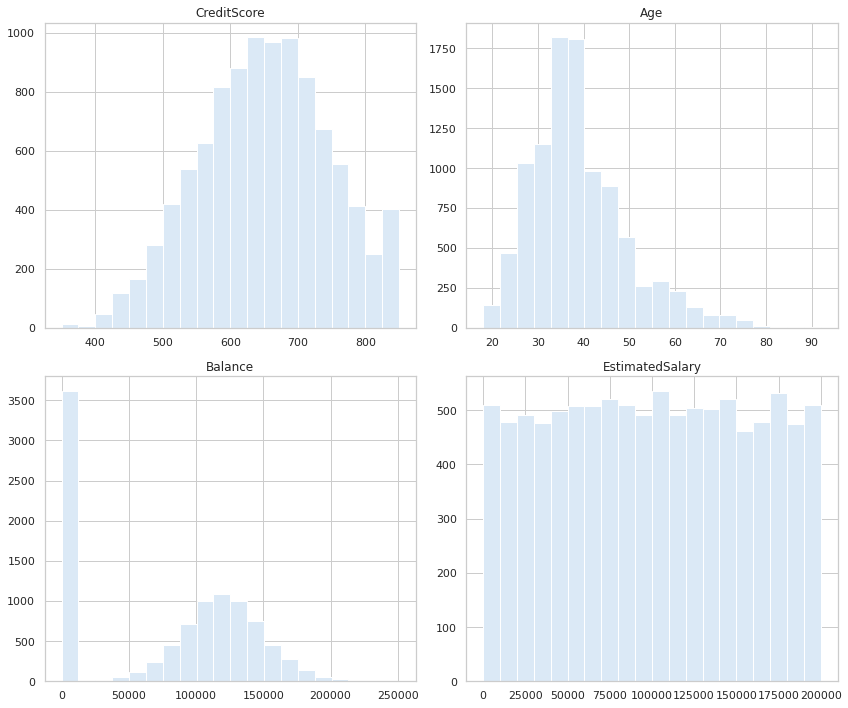

In [19]:
# визуализация прочих чиловых признаков
df[['CreditScore', 'Age', 'Balance', 'EstimatedSalary']].hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

Кредитный рейтинг и баланс счета клиентов распределен близко к нормальному распредлению, что довольно странно. Результат дейтельности (поведения) человека, а особенно его денежная оценка обычно имеют "жирные" хвосты. Представленные на анализ данные, в этой части, стали для автора приятной неожиданностью.

Возраст - классический пример нормального распределения данных. Датасет - подтверждает теория в этой части. Клиенты банка представлены в возрасте примерно от 20 до 90 лет, со среднем возрастом примерно в районе 35 лет.

Оценка дохода клиентов банков имеет равнмерное распределение. В представленных на анализ данных практически равное число клиентов имеет доход от нуля до 200 000 у.е., что также вызывает сомнение - "денежная оценка" результата деятельности человека в нормальных условиях распределена с сильным правосторонним скосом. Аналогично отмеченным автором выше распределением банковского скора.

В совакупности распределение креитных рейтингов и доходов клиента может свидельствовам о систетическом наборе данных, представленного на исследование.

Однако, данные имеют разную размерность. Так, например, скоринг примерно от нуля до 900, а баланс примерно от нуля до 250 000 у.е. Для корректной работы алгоритма обучения следует привести данные к единой размерности.

Но для начала отберем необходимые для обучения модели признаки.

### Исследование номинативных признаков. Кодировка данных

Перед кодирование категориальных признаков, проверим последнии на аналичие аномальных сведений.

,Geography_share
France,0.5014
Germany,0.2509
Spain,0.2477


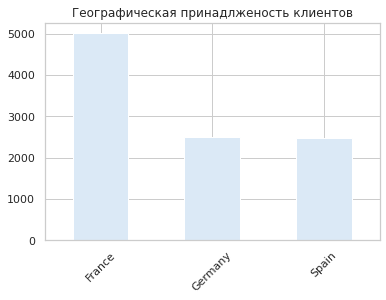

,Gender_share
Male,0.5457
Female,0.4543


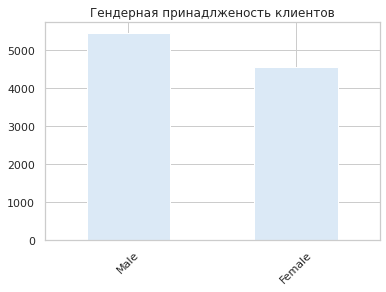

In [20]:
# изучение географии клиента, проверка на аномальность данных
display(df['Geography']
        .value_counts(normalize=True)
        .to_frame()
        .rename({'Geography': 'Geography_share'}, axis=1))

# визуализация соотношения локаций клиентов
df['Geography'].value_counts().plot(kind='bar', rot=45)
plt.title('Географическая принадлженость клиентов')
plt.show()


# изучение пола клиента, проверка на аномальность
display(df['Gender']
        .value_counts(normalize=True)
        .to_frame()
        .rename({'Gender': 'Gender_share'}, axis=1))

# визуализация соотношения локаций клиентов
df['Gender'].value_counts().plot(kind='bar', rot=45)
plt.title('Гендерная принадлженость клиентов')
plt.show()

Аномальных переменных не выявлено. Перекодируем данные методом унитарного кодирования, так чтобы в каждый конкретный момент времени активным (hot) может быть только один триггер состояния.

In [21]:
# OHE для перевода номинативных значени в числовые 
df = pd.get_dummies(df, 
                    columns=['Geography', 'Gender'], 
                    drop_first=True)

# отображение результата кодировки
df.head()

,CreditScore,Age,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Tenure,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,0.00,1,1,1,101348.88,1,2,0,0,0
1,608,41,83807.86,1,0,1,112542.58,0,1,0,1,0
2,502,42,159660.80,3,1,0,113931.57,1,8,0,0,0
3,699,39,0.00,2,0,0,93826.63,0,1,0,0,0
4,850,43,125510.82,1,1,1,79084.10,0,2,0,1,0


Перменные локации клиента и гендер перекодированы корректно.

Далее приведем к единой размерности чиловые признаки. Применем стандартизацию, предварительно разобьем выборку на обучающаю и тестовую.

### Сплит данных. Масштабирование чиловых признаков

In [22]:
# разделение данных на признаки и целевую переменную
X = df.drop('Exited', axis=1)
y = df['Exited']

# формирование обучающей и тестовой выборок
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=.2, 
                                                    random_state=42,
                                                    stratify=y)
# отображение результата деления
print(f'Размер обучающей матрицы, наблюдений: {X_train.shape[0]}; признаков {X_train.shape[1]}.')
print(f'Количество записей целевой переменной для обучающей выборки: {y_train.shape[0]}.')
print()
print(f'Размер тестовой матрицы, наблюдений: {X_test.shape[0]}; признаков {X_test.shape[1]}.')
print(f'Количество записей целевой переменной для тестовой выборки: {y_test.shape[0]}.')

Размер обучающей матрицы, наблюдений: 8000; признаков 11.
Количество записей целевой переменной для обучающей выборки: 8000.

Размер тестовой матрицы, наблюдений: 2000; признаков 11.
Количество записей целевой переменной для тестовой выборки: 2000.


Формирование обучающей и тестовой выборок произведено корректно.

In [23]:
# определение числовых признаков, подлежащих приведению к единой размерности
numeric = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'NumOfProducts', 'Tenure']

# инициализация модели стандартизации признака
scaler = StandardScaler()

# подгонка модели на обучающих данных 
scaler.fit(X_train[numeric])

# реализация модели на учебной и тестовой выборках
X_train[numeric] = scaler.transform(X_train[numeric])
X_test[numeric] = scaler.transform(X_test[numeric])

# отображение результата стандратизации
display(X_train[numeric].head())
X_test[numeric].head()

,CreditScore,Age,Balance,EstimatedSalary,NumOfProducts,Tenure
2151,1.058568,1.715086,-1.226059,1.042084,-0.910256,0.726623
8392,0.913626,-0.659935,0.413288,-0.623556,-0.910256,-0.698303
5006,1.079274,-0.184931,0.601687,0.308128,0.808830,-1.766997
4117,-0.929207,-0.184931,-1.226059,-0.290199,0.808830,0.014160
7182,0.427035,0.955079,0.548318,0.135042,0.808830,0.014160


,CreditScore,Age,Balance,EstimatedSalary,NumOfProducts,Tenure
5702,-0.680735,-0.279932,-1.226059,-0.095021,0.808830,0.726623
3667,-1.301915,-0.564935,0.877113,-0.778941,0.808830,-0.342071
1617,-0.970619,0.100072,-1.226059,0.099469,0.808830,-0.342071
5673,-0.121674,-0.469934,1.011458,-1.147374,0.808830,0.014160
4272,-0.111321,-0.469934,0.023204,1.200283,-0.910256,-0.698303


Числовые признаки стандартизированы корректны. Изучим изменение распределение последних.

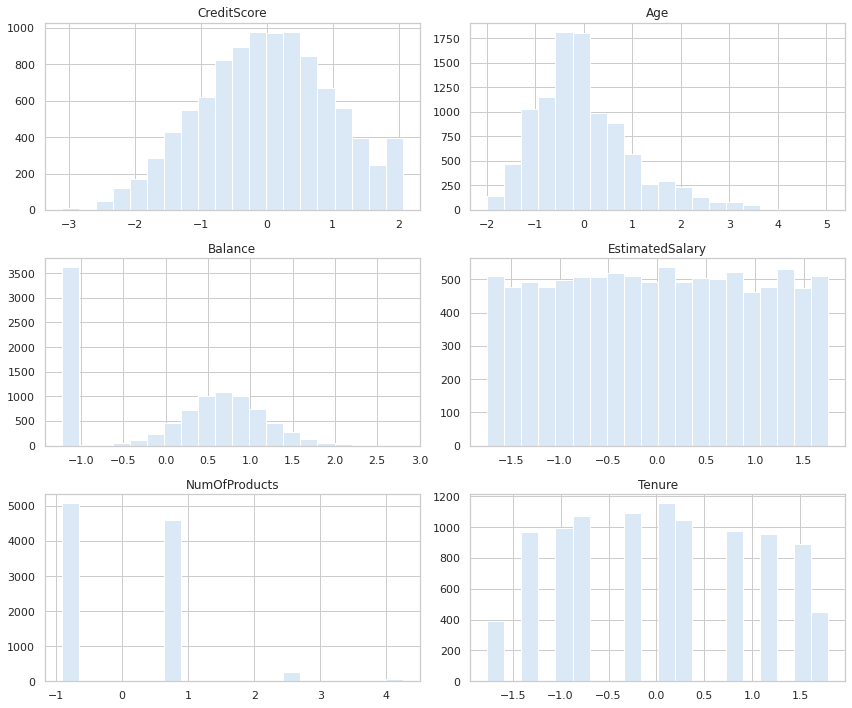

In [24]:
# распределение стандартизированных числовых признаков
pd.concat([X_train[numeric], X_test[numeric]]).hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

Числовые признаки приняли распределение со среднем значением в нуле и стандартным отлонением равным единице. Признаки масштаброваны.

Таким образом, признаки для обучения модели отобраны, предобработаны, приведены к необходимым типам данных. Категориальные переменные перекодированы, числовые признаки масшабированы.

Приступим к исследованию задачи.

## Исследование задачи
### Анализ баланса целевого класса

Изучим соотношение целевого класса. Количество положительных клиентов - расторгнувших договор банковского обслуживания и негативных - оставшихся клиентами.

,Exited_share
0,0.7963
1,0.2037


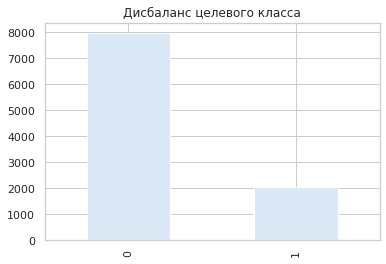

,Exited_train_sample_share
0,0.79625
1,0.20375


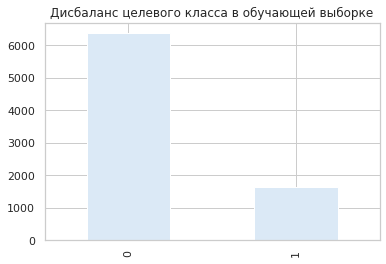

,Exited_test_sample_share
0,0.7965
1,0.2035


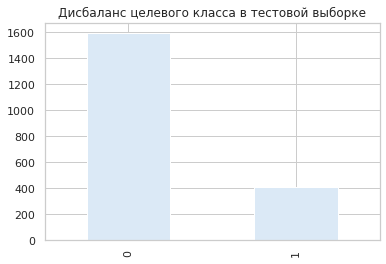

In [25]:
# расчет соотношения целевого класса во всех представленных данных
display(y.value_counts(normalize=True)
        .to_frame()
        .rename({'Exited': 'Exited_share'}, axis=1))

# визуализация соотношения целевого класса
y.value_counts().plot(kind='bar')
plt.title('Дисбаланс целевого класса')
plt.show()

# расчет соотношения целевого класса в тренировочной выборке
display(y_train.value_counts(normalize=True)
        .to_frame()
        .rename({'Exited': 'Exited_train_sample_share'}, axis=1))

# визуализация соотношения целевого класса
y_train.value_counts().plot(kind='bar')
plt.title('Дисбаланс целевого класса в обучающей выборке')
plt.show()

# расчет соотношения целевого класса в тестовой выборке
display(y_test.value_counts(normalize=True)
        .to_frame()
        .rename({'Exited': 'Exited_test_sample_share'}, axis=1))

# визуализация соотношения целевого класса
y_test.value_counts().plot(kind='bar')
plt.title('Дисбаланс целевого класса в тестовой выборке')
plt.show()

Таким образом, целевая переменная несбалансирована.

Проведем эксперимент. Обучим модели логистической регрессии, дерево решений и случайного леса с дисбалансом класса и оценим метрику F1 и AUC-ROC на несбалансированных моделях.

###  Функция для исследования задачи. Описание F1 и AUC-ROC метрик

Объявим функция, которая будет принимать на вход модель и выдавать F1 и AUC-ROC метрики.

In [26]:
# объявление функции для исследования моделей
def model_reserch(model):
    # обучение модели
    model.fit(X_train, y_train)
    
    # заключения модели по распознанию класса
    y_pred = model.predict(X_test)
    # скор модели по позитивной оценке целевого класса
    y_score = model.predict_proba(X_test)[:, 1]
    
    # отображение метрик F1 и AUC-ROC модели
    print(f'F1 score: {f1_score(y_test, y_pred):.4f}')
    print(f'AUC-ROC score: {roc_auc_score(y_test, y_score):.4f}')
    
    # расчет полноты и точности при различных скорах модели
    precision, recall, thresholds = precision_recall_curve(y_test, y_score)
    # расчет доли ложноположительного класса и полноты модели при различных скорах модели
    fpr, tpr, thresholds = roc_curve(y_test, y_score)
    
    # визуализация кривых Precision-Recall и ROC
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.step(recall, precision, where='post')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.ylim([0.0, 1.0])
    plt.xlim([0.0, 1.0])
    plt.title('Кривая Precision-Recall')

    plt.subplot(1, 2, 2)
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('False positive rate')
    plt.ylabel('True positive rate')
    plt.title('ROC-кривая')

    plt.show()

Метрика F1 - представляет собой гармоническое среднее между точность и полнотой оценкой модели признаков. 

В связи с чем, высокое значение метрика принимает только в том случае, если и точность и полнота находятся на достатосчно высоком уровне.

График взаимоотношения метрики точности (Precision) и полноты (Recall) демострирует, что с увеличем полноты, то есть охвата моделью положительного класса, точность определения положитеьлного класса снижается.

Метрика AUC-ROC, определяется, как площадь под кривой ROC. В свою очереь график ROC демостриует отношение долей верно предсказанных объектов к общему числу объектов класса (True positive rate) и долей ложных срабатываний к общему числу объектов за пределами класса (False positive rate).

График ROC демонстрирует, что с увеличем полноты охвата, увеличивается и доля ложных откликов.

Таким образом, метрик F1 и AUC-ROC коррелирует между собой по показателю "полноты" (Recall - для F1 и True positive rate - для AUC-ROC): с увеличем полноты охвата точность (Precision для F1) будет снижаться, а количество ложных срабатываний (False positive для AUC-ROC) будет расти.

Докажем это утверждение экспериментально.

### Логистическая регрессия

F1 score: 0.2873
AUC-ROC score: 0.7749


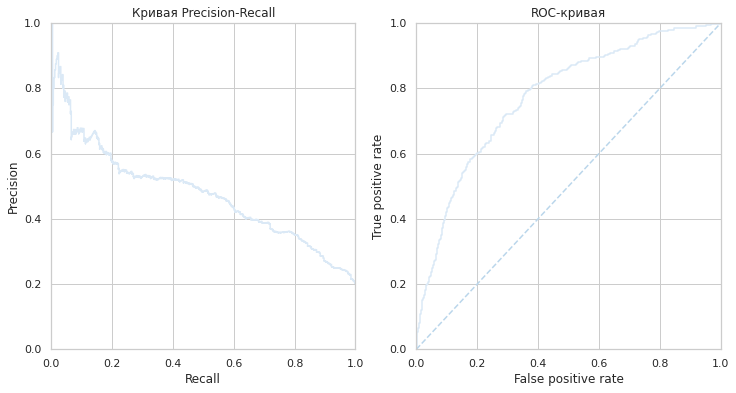

In [27]:
# инициализация модели логистической регрессии
model = LogisticRegression(random_state=42, 
                           solver='liblinear')

# вызов функции для оценки модели
model_reserch(model)

Модель логистической регрегсии, обученная на несбалансированной выборки продемонстрировала досточно низкие значения метрик F1 и AUC-ROC, 0,2873 и 0,7748.

Таким образом, модель логистической регрессии чувствительна к дисбалансу целевого класса.

Далее изучим влияние дисбаланса выборки на модель решающего дерева.

### Дерево решений
#### Гиперпараметры по умолчанию

F1 score: 0.4958
AUC-ROC score: 0.6855


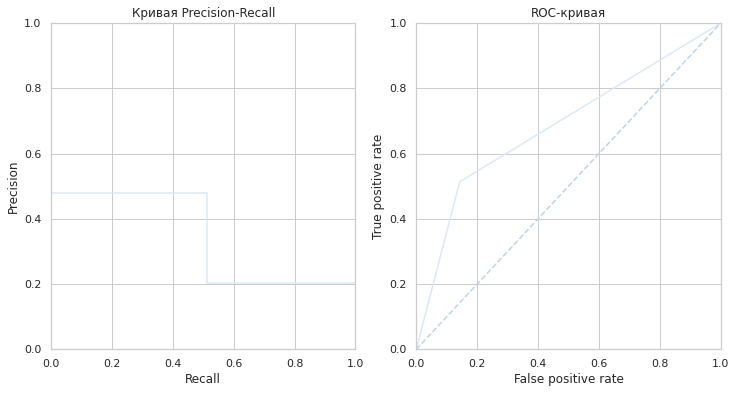

In [28]:
# инициализация модели решающего дерева
model = DecisionTreeClassifier(random_state=42)

# вызов функции для оценки модели
model_reserch(model)

Для модели решающего дерева баланс класса менее важен, метрика F1 составила 0,5030 (против 0,2873 у модели логистической регрессии), а вот метрика AUC-ROC неслоколько ниже - 0,6901 (против 0,7748 у модели логистической регрессии). При этом лучшее соотношение между полнотой и точности модели, также, как и у логистической регрессии у отметки примерно в 0,5 по точности.

Улучшим модель решающего дерева, подберем оптимальные гиперпараметры.

#### Подбор гиперпараметров

In [29]:
# формирование сетки гиперпараметров
#params = {'max_depth': range (3, 13, 2),
#          'min_samples_leaf': range (2, 9),
#          'min_samples_split': range (2,10,2)}

# инициализация и обучение модели подбора гоперпараметров с кросс-валидацией
#grid = GridSearchCV(model, params, cv=5)
#grid.fit(X_train, y_train)

# вывод оптимальных гиперпараметров 
#grid.best_params_

#### Оптимальные параметры

F1 score: 0.5470
AUC-ROC score: 0.8039


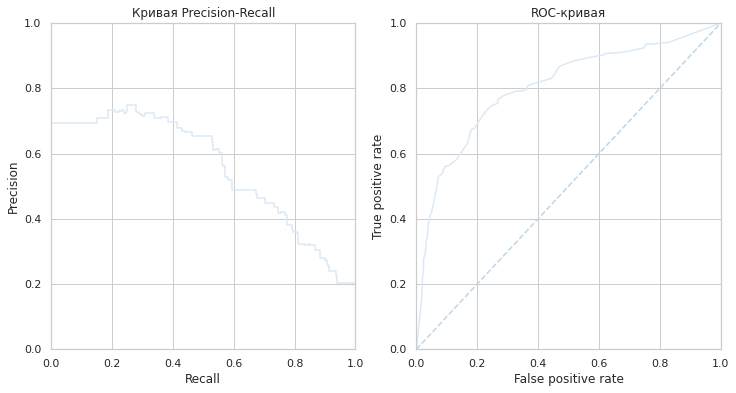

In [30]:
# инициализация модели решающего дерева с подобранными гиперпараметрами
model = DecisionTreeClassifier(max_depth=9,
                               min_samples_leaf=3, 
                               min_samples_split=2, 
                               random_state=42)

# вызов функции для оценки модели
model_reserch(model)

Подобранные гиперпараметры значительно уличшили предсказательные возможности модели, F1 увеличилась до 0,5650, AUC-ROC до 0,8048, превысив установленный стейкхолдером поруг по F1 в 0,56.

Таким образом, улучшив метрику F1 за счет точности, улучшаеться и метрика AUC-ROC за счет снижения числа ложных срабатываний.

Таким образом, модель решающего дерева с оптимальными гиперпараметрами позволяет решать задачу заказчика на несбалансированной выборке.

Узучим предсказательные способности модели случайного леса на несбалансированной выборке.

### Случайный лес
#### Гиперпараметры по умолчанию

F1 score: 0.5688
AUC-ROC score: 0.8500


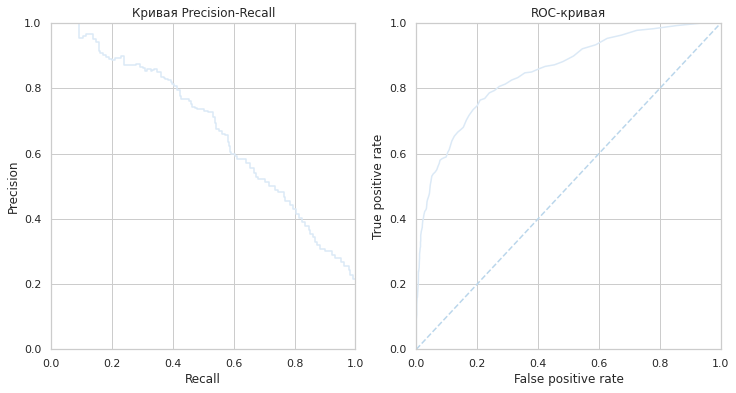

In [31]:
# инициализация модели случайного леса
model = RandomForestClassifier(random_state=42)

# вызов функции для оценки модели
model_reserch(model)

С дефолтными гиперпараметрами модель случайного леса продемонстрировала лучшие на данному этапе показатели, - F1 0,5697 (против 0,2873 у логистической регрессии и 0,5650 у решающего дерева) и AUC-ROC 0,8506 (против 0,7748 у логистиечской регрессии и 0,8048 у решающего дерева). 

Таким образом, из всех рассмотренных моделей - случайный лес менее чувствителем к дисбалансу.

Таким образом, модель случайного леса с дефолтными гиперпараметрами на несбалансированной выборке позволяет решить поставленную задачу превысив отметку в 0,56 по метрике F1.

Улучшим модель случайного леса, подберем оптимальные гиперпарметры.

#### Подбор гиперпараметров

In [32]:
# формирование сетки гиперпараметров
#params = {'n_estimators': range(10, 110, 10),
#          'max_depth': range (3, 13, 2),
#          'min_samples_leaf': range (2, 9),
#          'min_samples_split': range (2,10,2)}

# инициализация и обучение модели подбора гоперпараметров с кросс-валидацией
#grid = GridSearchCV(model, params, cv=5)
#grid.fit(X_train, y_train)

# вывод оптимальных гиперпараметров 
#grid.best_params_

#### Оптимальные гиперпараметры

F1 score: 0.5751
AUC-ROC score: 0.8627


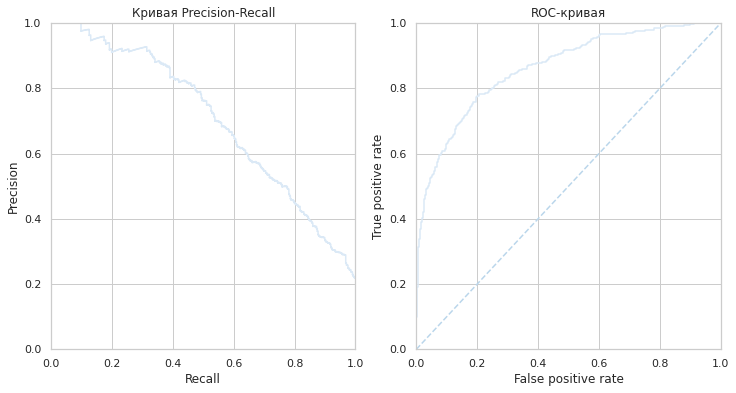

In [33]:
# инициализация модели с оптимальными гиперпараметрами
model = RandomForestClassifier(n_estimators=90,
                               max_depth=11,
                               min_samples_leaf=3, 
                               min_samples_split=4, 
                               random_state=42)

# вызов функции для анализа модели
model_reserch(model)

Подбор гиперпараметров улучшил значение метрик F1 до 0,5858 и AUC-ROC до 0,8628.

Таким образом, улучшив метрику F1 за счет точности, улучшаеться и метрика AUC-ROC за счет снижения числа ложных срабатываний.

## Борьба с дисбалансом

Бланасирование выборки будем проводить путем взвешивания классов (отстающему классу будет присвоим больший вес), увелечения выборки за счет минорного класса, снижение выборки за счет доминируещего класса.

### Увеличение выборки

Объявим функцию, которая будет принимать признаки, целевую переменную и коэффициент разницы между классами, а возвращать сбалансированную выборку за счет клонирования, представленного в меньшей степени класса.

In [55]:
# функция для увеличения количества положительного класса в выборке
def upsample(features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)
    
    features_upsampled, target_upsampled = shuffle(
        features_upsampled, target_upsampled, random_state=42)
    
    return features_upsampled, target_upsampled

(12890, 11)

,Exited
1,0.505818
0,0.494182


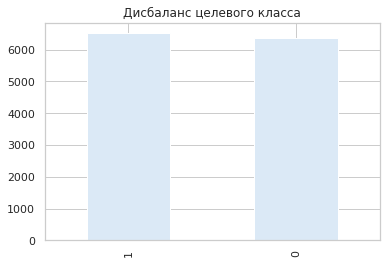

In [35]:
# увеличение в обучающей выборке положительного класса
X_train_upsampled, y_train_upsampled = upsample(X_train, y_train, 4)

# отображение матрицы признаков, после процедуры upsampling
display(X_train_upsampled.shape)

# расчет соотношения целевого класса
display(y_train_upsampled.value_counts(normalize=True).to_frame())

# визуализация соотношения целевого класса
y_train_upsampled.value_counts().plot(kind='bar')
plt.title('Дисбаланс целевого класса')
plt.show()

Таким образом, классы сбалансированы. Число наблюдений увеличено с 10 000 до 12 890.

### Уменьшение выборки

Объявим функцию, которая будет принимать на вход признаки, целевую переменную и долю, на которую следует уменьшить число наблюдений, которым соответсвует доминирующий класс.

In [36]:
# функция для уменьшения количества отрицательного класса в выборке
def downsample(features, target, fraction):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_downsampled = pd.concat(
        [features_zeros.sample(frac=fraction, random_state=42)] + [features_ones])
    target_downsampled = pd.concat(
        [target_zeros.sample(frac=fraction, random_state=42)] + [target_ones])
    
    features_downsampled, target_downsampled = shuffle(
        features_downsampled, target_downsampled, random_state=42)
    
    return features_downsampled, target_downsampled

(3222, 11)

,Exited
1,0.505897
0,0.494103


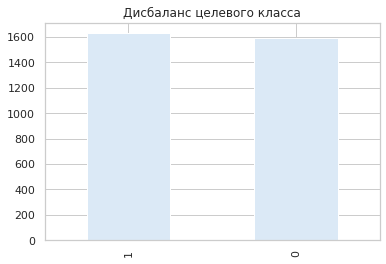

In [37]:
# снижение в обучающей выборке отрицательного класса
X_train_downsampled, y_train_downsampled = downsample(X_train, y_train, 0.25)

# отображение матрицы признаков, после процедуры upsampling
display(X_train_downsampled.shape)

# расчет соотношения целевого класса
display(y_train_downsampled.value_counts(normalize=True).to_frame())

# визуализация соотношения целевого класса
y_train_downsampled.value_counts().plot(kind='bar')
plt.title('Дисбаланс целевого класса')
plt.show()

Таким образом, выборка сбалансирована. Число наблюдений снизилось с 10 000 до 3 222.

### Балансировка выборки методом SMOTE


(12740, 11)

,Exited
1,0.5
0,0.5


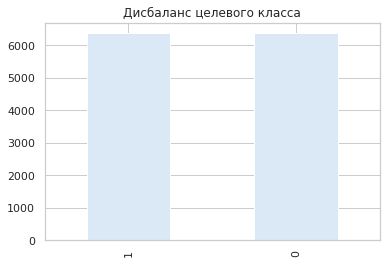

In [59]:
# инициализация SMOTE
sm = SMOTE(random_state=42)

# баланировака класса методом SMOTE
X_train_resample, y_train_resample = sm.fit_resample(X_train, y_train)

# отображение матрицы признаков, после процедуры SMOTE
display(X_train_resample.shape)

# расчет соотношения целевого класса
display(y_train_resample.value_counts(normalize=True).to_frame())

# визуализация соотношения целевого класса
y_train_resample.value_counts().plot(kind='bar')
plt.title('Дисбаланс целевого класса')
plt.show()

Таким образом, выборка сбалансиловалась. Число наблюдений выросто с 10 000 до 12 740.

### Функция для исследования задачи на увеличенной выборке

Объявим функцию, которая будет исследовать модель на увеличенной сбалансированной выборке.

In [38]:
# объявление функции для исследования моделей с увеличением в выборке положительного класса
def model_reserch_upsampling(model):
    # обучение модели на увеличенной за счет положеительного класса выборки
    model.fit(X_train_upsampled, y_train_upsampled)
    
    # заключения модели по распознанию класса
    y_pred = model.predict(X_test)
    # скор модели по позитивной оценке целевого класса
    y_score = model.predict_proba(X_test)[:, 1]
    
    # отображение метрик F1 и AUC-ROC модели
    print(f'F1 score: {f1_score(y_test, y_pred):.4f}')
    print(f'AUC-ROC score: {roc_auc_score(y_test, y_score):.4f}')
    
    # расчет полноты и точности при различных скорах модели
    precision, recall, thresholds = precision_recall_curve(y_test, y_score)
    # расчет доли ложноположительного класса и полноты модели при различных скорах модели
    fpr, tpr, thresholds = roc_curve(y_test, y_score)
    
    # визуализация кривых Precision-Recall и ROC
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.step(recall, precision, where='post')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.ylim([0.0, 1.0])
    plt.xlim([0.0, 1.0])
    plt.title('Кривая Precision-Recall')

    plt.subplot(1, 2, 2)
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-кривая')

    plt.show()

### Функция для исследования задачи на уменьшенной выборке

Объявим функцию, которая будет исследовать модель на уменьшенной сбалансированной выборке.

In [39]:
# объявление функции для исследования моделей с увеличением в выборке положительного класса
def model_reserch_downsampling(model):
    # обучение модели на увеличенной за счет положеительного класса выборки
    model.fit(X_train_downsampled, y_train_downsampled)
    
    # заключения модели по распознанию класса
    y_pred = model.predict(X_test)
    # скор модели по позитивной оценке целевого класса
    y_score = model.predict_proba(X_test)[:, 1]
    
    # отображение метрик F1 и AUC-ROC модели
    print(f'F1 score: {f1_score(y_test, y_pred):.4f}')
    print(f'AUC-ROC score: {roc_auc_score(y_test, y_score):.4f}')
    
    # расчет полноты и точности при различных скорах модели
    precision, recall, thresholds = precision_recall_curve(y_test, y_score)
    # расчет доли ложноположительного класса и полноты модели при различных скорах модели
    fpr, tpr, thresholds = roc_curve(y_test, y_score)
    
    # визуализация кривых Precision-Recall и ROC
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.step(recall, precision, where='post')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.ylim([0.0, 1.0])
    plt.xlim([0.0, 1.0])
    plt.title('Кривая Precision-Recall')

    plt.subplot(1, 2, 2)
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-кривая')

    plt.show()

### Логистическая регрессия
#### Взвешивание класса

F1 score: 0.4996
AUC-ROC score: 0.7773


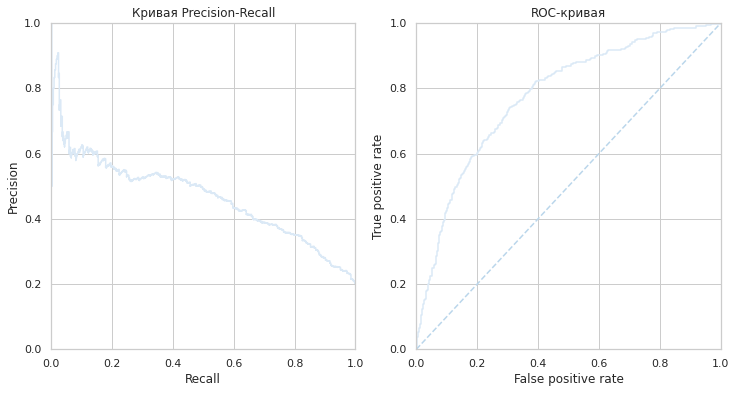

In [40]:
# инициализация модели логистической регрессии с взвешенными классами
model = LogisticRegression(random_state=42, 
                           solver='liblinear',
                           class_weight='balanced') # взвешивание классов

# вызов функции для оценки модели
model_reserch(model)

Взвешивание класса в модели логистической регрессии увеличило значение метрики F1 c 0,2873 до 0,4983; значение метрики AUC-ROC с 0,7748 до 0,7771.

Таким образом, взешивание классов положительно сказывается на модели логистической регрессии.

Таким образом, улучшив метрику F1, улучшаеться и метрика AUC-ROC.

#### Upsampling

F1 score: 0.5000
AUC-ROC score: 0.7773


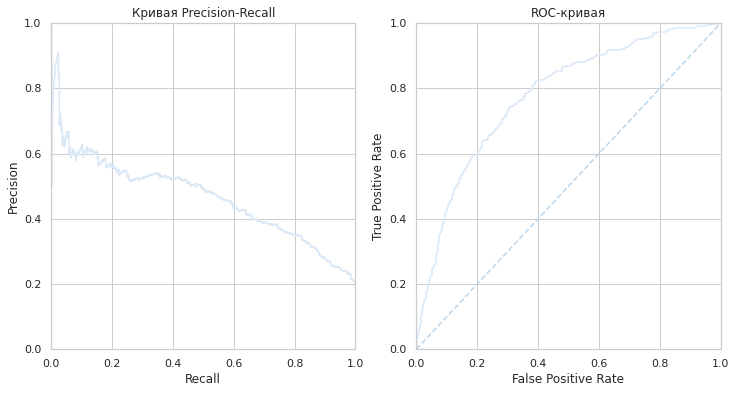

In [41]:
# инициализация модели логистической регрессии
model = LogisticRegression(random_state=42, 
                           solver='liblinear')

# вызов функции для исследования модели на сбалансированной увеличенной выборке
model_reserch_upsampling(model)

Сбалансированная увелеченная выборка сохранила показатели метрик на прежнем уровне.

Таким образом, для моделей логистической регресии взвешивание классов и upsampling имеет равное значение.

#### Downsampling

F1 score: 0.5004
AUC-ROC score: 0.7748


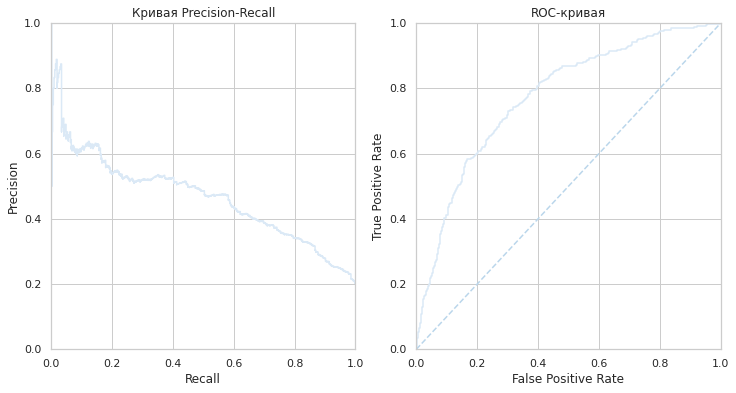

In [42]:
# вызов функциии для исследования модели на сбалансированной уменьшенной выборке
model_reserch_downsampling(model)

Сбалансированная уменьшенная выборка несколько снизило показатели метрик, F1 до 0,4983; AUC-ROC до 0,7747. 

Однако, возможно, при многоратном повторении эксперимента, например, в ходе процедуры кросс-валидации, среднее значение метрик окажется в значении референтных границ и применение процедур взвешивания классов, увелечение или снижение выборки не будет иметь статистически значимых различий. Настоящее исследование не ставит задачу проверку выдвинутой гипотезы.

Таким образом, для моделей логистической регресии взвешивание классов, upsampling и downsampling имеет равное значение.

### Дерево решений
#### Взвешивание классов

F1 score: 0.5389
AUC-ROC score: 0.7849


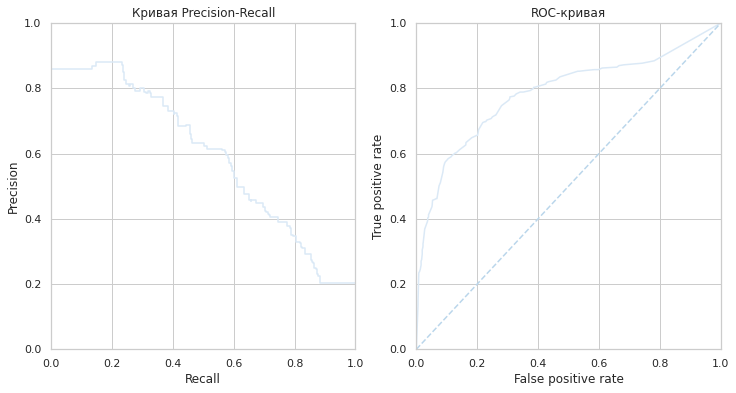

In [43]:
# инициализация модели решающего дерева со взвешенными классами
model = DecisionTreeClassifier(max_depth=9,
                               min_samples_leaf=3, 
                               min_samples_split=2, 
                               class_weight='balanced', # взвешивание классов
                               random_state=42)

# вызов функции для исследования модели 
model_reserch(model)

Модель дерева решений, построенная на взвешивание класов оказалась несльколько хуже модели построенной на несбалансированной выборке: Метрика F1 снизилас с 0,5650 до 0,5432; метрика AUC-ROC снизилась с 0,8048 до 0,7892.

Таким образом, вывод о устойчивости модели решающего дерева к дисбалансу выборки дополнительно подтверждается.

Дополнительно и подверждается взаимосвязь метрик F1 и AUC-ROC: падение одной, влечет снижение другой.

#### Upsampling

F1 score: 0.5328
AUC-ROC score: 0.7803


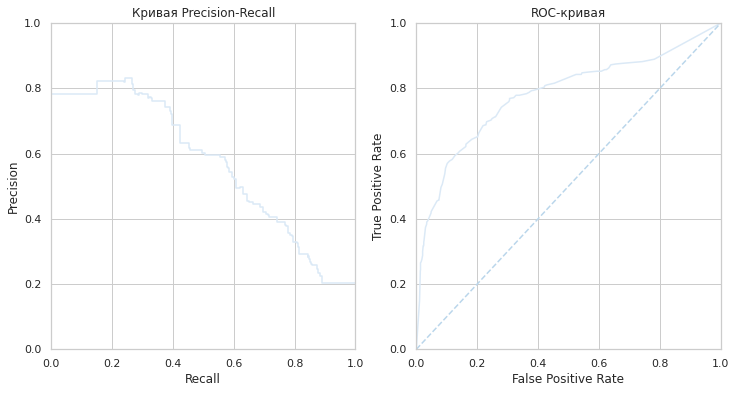

In [44]:
# инициализация модели решающего дерева
model = DecisionTreeClassifier(max_depth=9,
                               min_samples_leaf=3, 
                               min_samples_split=2, 
                               random_state=42)

# вызов функции для исследования модели на сбалансирвоанной увеличенной выборке
model_reserch_upsampling(model)

При балансироваки классов за счет увеличении выборки, качество модели решающего дерева продложает снижаться: метрики F1 - 0,5344, AUC-ROC - 0,7803.

Возможно, качество метрик снизилось из-за получения моделью излищней информации для построения ветвей дерева, за счет синтетического увеличения выборки клонами.

#### Downsampling

F1 score: 0.5432
AUC-ROC score: 0.8014


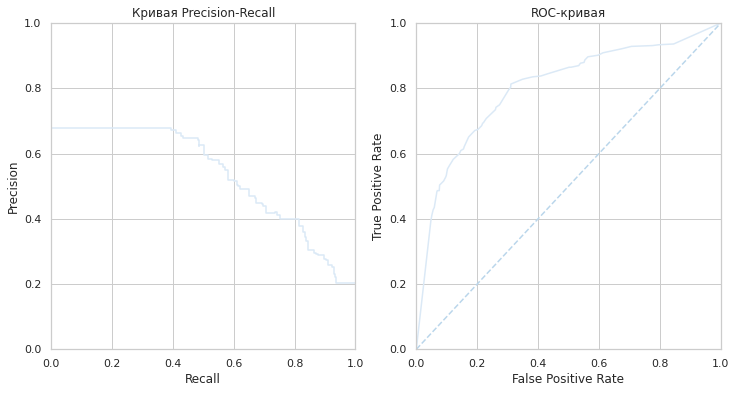

In [45]:
# вызов функции для исследования модели на уменьенной сблансированной выборки
model_reserch_downsampling(model)

Снижение выборки, напротив улучает качество модели: F1 выросла до 0,5871; AUC-ROC увеличилась до 0,8646.

Возможно, улучшение метрик, связно с сокращение информации, что благотворно сказывается на ветвлении дерева.

Далее изучим влияние балансировки выборки на модель случайного леса.

### Случайный лес
#### Взвешивание классов

F1 score: 0.6305
AUC-ROC score: 0.8641


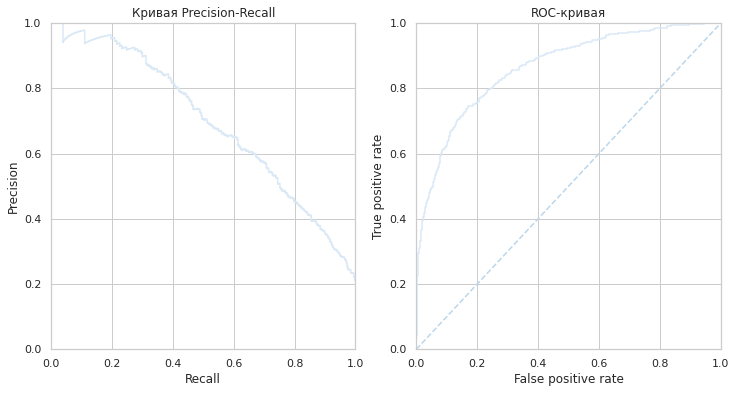

In [46]:
# инициализация модели случайного леса со взвешивание классов
model = RandomForestClassifier(n_estimators=70,
                               max_depth=9,
                               min_samples_leaf=3, 
                               min_samples_split=2, 
                               class_weight='balanced', # взвешивание классов
                               random_state=42)

# вызов функции для исследования модели
model_reserch(model)

Взвешивание классов улучишило метрику F1 с 0,5858 до 0,6233; метрику AUC-ROC с 0,8628 до 0.8634.

Таким образом, взвешивание классов положительно сказывается на оценочных характеристиках модели случайного леса.

Кроме того, дополнительно подтверждается, что с улучшением F1, увеличиваеться и прощадь под кривой ROC, - график больше тяготеет к левому верхнему углу.

#### Upsampling

F1 score: 0.6193
AUC-ROC score: 0.8668


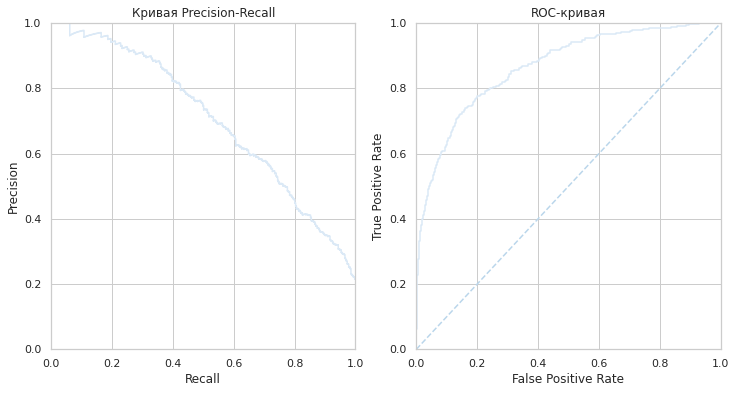

In [47]:
# инициализация модели случайного леса
model = RandomForestClassifier(n_estimators=70,
                               max_depth=9,
                               min_samples_leaf=3, 
                               min_samples_split=2, 
                               random_state=42)

# вызов функции для исследовании модели на сбалансированной увеличенной выборки
model_reserch_upsampling(model)

Увеличение выборки незначительно снизило качество модели: F1 до 0,6162; AUC-ROC до 0,8662.

На снижение качетсва модели могло повлиять излишняя информативность выборки, в связи с клонированием наблюдений.

#### Downsampling

F1 score: 0.5931
AUC-ROC score: 0.8655


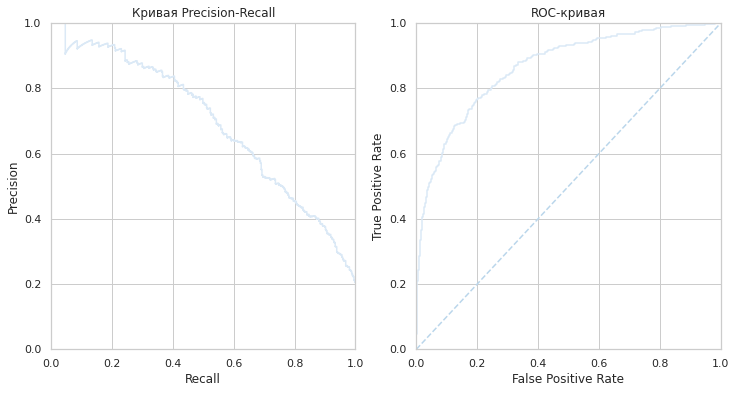

In [48]:
# вызов функции для исследования модели на сбалансирвоанной уменьшенной выборке
model_reserch_downsampling(model)

Уменьшение выборки продолжило снижать качество модели случайного леса: F1 составила 0,5934; AUC-ROC составила 0,8636.

Снижение качества модели могло произойти вследствии снижения выборки и, соответсвенно, недостаточного количества числа наблюдений для подгонки модели.

Однако, скорее всего, показатели метрик не имеют статитически значимых различий при балансировки классов, увеличении и снидении выборки. И в целом, модель случайного леса, как и модель дерева решений робастны к дисбалансу классов.

Подведем итог эксперимента. Выберем лучшую из изученных моделей для тестирования.

### Summary по экспериметам с балансирвоание выборки
#### Логистическая регрессия

,default,class_weigth,upsampling,downsampling
F1_score,0.2873,0.5004,0.5004,0.4983
AUC_ROC_score,0.7748,0.7771,0.7771,0.7747


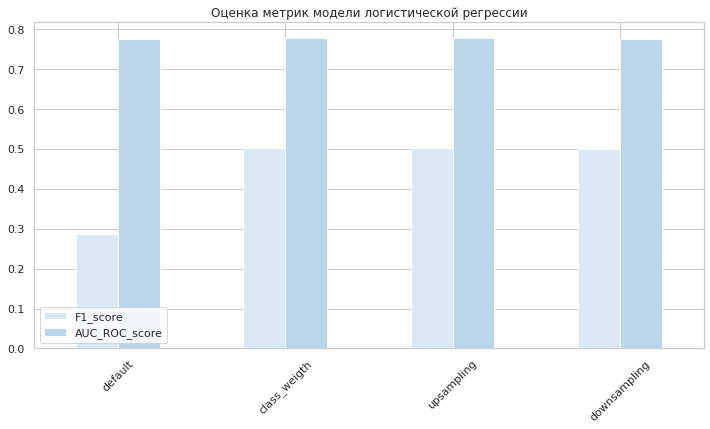

In [49]:
# формирование сводной таблицы со значения метрик, полученных в ходе эксперимента
log_reg_score = pd.DataFrame({'default': [0.2873, 0.7748],
              'class_weigth': [0.5004, 0.7771],
              'upsampling': [0.5004, 0.7771],
              'downsampling': [0.4983, 0.7747]}, 
             index=['F1_score', 'AUC_ROC_score'])

# отображение результата
display(log_reg_score)

# визуализация результата
log_reg_score.T.plot(kind='bar', figsize=(12, 6), rot=45)
plt.legend(loc='lower left')
plt.title('Оценка метрик модели логистической регрессии')
plt.show()

#### Решающее дерево

,default,tuning,class_weigth,upsampling,downsampling
F1_score,0.5030,0.5650,0.5432,0.5344,0.5871
AUC_ROC_score,0.6901,0.8048,0.7892,0.7803,0.8646


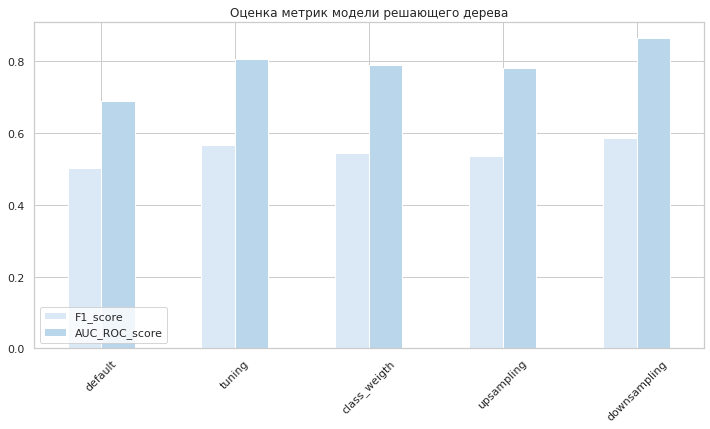

In [50]:
# формирование сводной таблицы со значения метрик, полученных в ходе эксперимента
dec_tree_score = pd.DataFrame({'default': [0.5030, 0.6901],
                              'tuning': [0.5650, 0.8048],
                              'class_weigth': [0.5432, 0.7892],
              'upsampling': [0.5344, 0.7803],
              'downsampling': [0.5871, 0.8646]}, 
             index=['F1_score', 'AUC_ROC_score'])

# отображение результата
display(dec_tree_score)

# визуализация результата
dec_tree_score.T.plot(kind='bar', figsize=(12, 6), rot=45)
plt.legend(loc='lower left')
plt.title('Оценка метрик модели решающего дерева')
plt.show()

#### Случайный лес

,default,tuning,class_weigth,upsampling,downsampling
F1_score,0.5697,0.5858,0.6233,0.6162,0.5934
AUC_ROC_score,0.8506,0.8628,0.8634,0.8662,0.8636


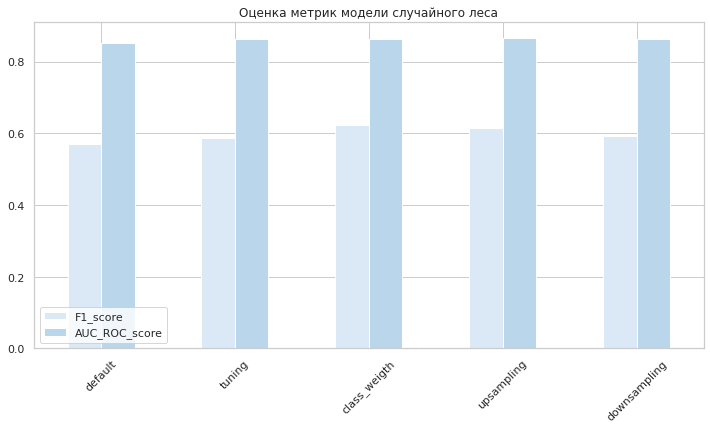

In [51]:
# формирование сводной таблицы со значения метрик, полученных в ходе эксперимента
rand_forest_score = pd.DataFrame({'default': [0.5697, 0.8506],
                              'tuning': [0.5858, 0.8628],
                              'class_weigth': [0.6233, 0.8634],
              'upsampling': [0.6162, 0.8662],
              'downsampling': [0.5934, 0.8636]}, 
             index=['F1_score', 'AUC_ROC_score'])

# отображение результата
display(rand_forest_score)

# визуализация результата
rand_forest_score.T.plot(kind='bar', figsize=(12, 6), rot=45)
plt.legend(loc='lower left')
plt.title('Оценка метрик модели случайного леса')
plt.show()

Таким образом, экпериметально доказана связь метрик F1 и AUC-ROC по показателю "полноты" (Recall - для F1 и True positive rate - для AUC-ROC): с увеличем полноты охвата точность (Precision для F1) будет снижаться, а количество ложных срабатываний (False positive для AUC-ROC) будет расти. При этом, при оптимальном определении трешхолда (отсечки срока модели для отнесения целевой переменной к определнному классу) с улучшением F1, площадь под кривой ROC будет увеличиваться и стремиться к единице за счет тяготения графика ROC к левому верхнему углу системы координат.


Оптимальной модели для поставленной задачи следует признать модель случайного леса, основанной на взвешивание классов с метрикой F1 равной 0,6162; метрикой AUC-ROC равной 0,8634.

## Тестирование модели
### Проверка модели на адекватность

Перед тестирование модели определимся с baseline алгоритма, ем самым проверим модель на адекватность. 

В качество отправной точки будем испольовать алгоритм прогнозирования, без использования признаков наблюдений, со стратификацией, так, чтобы каждая метка имела одинковое распределение и была независима.

F1 score: 0.1873
AUC-ROC score: 0.4885


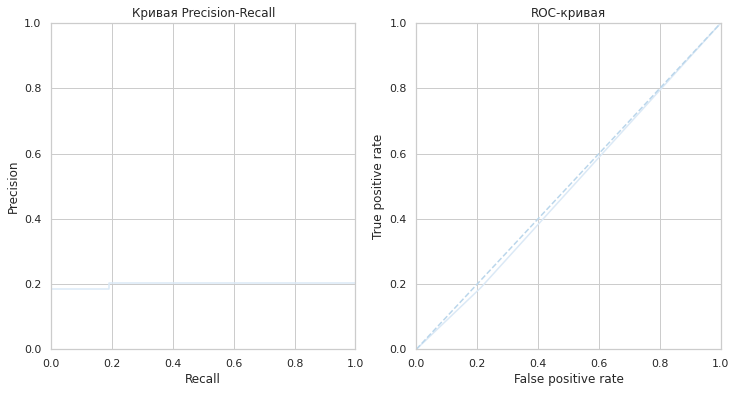

In [52]:
# инициализация модели классификатора
model = DummyClassifier(strategy='stratified', random_state=42)

# вызов функции для оценки модели
model_reserch(model)

Таким образом, все рассмотренные в исследовании модели являются достаточно адекватными. Оценки моделей явно превосходят "случайную" модель с метриками F1 - 0,1873 и AUC-ROC - 0,4885.

Далее протестируем оптимальную модель распознания классов, оценим ее обощающую способность.

### Проверка обощающей возможности модели
Объявим функцию, которая на вход будет принимать модель, а возвращать оценку модели по заявленнум стекхолдером метрикам, при этом модель будет делать прогноз, как на известной выборке, так и по новым данным, тем самым представляется возмодность оценить степень переобучения и, соответсвенно, обощающую способность модели.

In [53]:
# объявление функции для исследования моделей
def model_reserch_overfitting(model):
    # обучение модели
    model.fit(X_train, y_train)
    
    # заключения модели по распознанию класса на обучающей выборке
    y_pred_train = model.predict(X_train)
    # скор модели по позитивной оценке целевого класса на обучающей выборке
    y_score_train = model.predict_proba(X_train)[:, 1]
    
    # заключения модели по распознанию класса на тестовой выборке
    y_pred = model.predict(X_test)
    # скор модели по позитивной оценке целевого класса на тестовой выборке
    y_score = model.predict_proba(X_test)[:, 1]
    
    # отображение метрик F1 и AUC-ROC на известных модели данных
    print(f'F1 score train: {f1_score(y_train, y_pred_train):.4f}')
    print(f'AUC-ROC score train: {roc_auc_score(y_train, y_score_train):.4f}')
    
    # отображение метрик F1 и AUC-ROC на неизвестных модели данных
    print(f'F1 score test: {f1_score(y_test, y_pred):.4f}')
    print(f'AUC-ROC score test: {roc_auc_score(y_test, y_score):.4f}')
    
    # расчет полноты и точности при различных скорах на известных модели данных
    precision_train, recall_train, thresholds_train = precision_recall_curve(y_train, y_score_train)
    # расчет доли ложноположительного класса и полноты модели при различных скорах
    # на известных модели данных
    fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_score_train)
    
    # расчет полноты и точности при различных скорах на неизвестных модели данных
    precision, recall, thresholds = precision_recall_curve(y_test, y_score)
    # расчет доли ложноположительного класса и полноты модели при различных скорах
    # на неизвестных модели данных
    fpr, tpr, thresholds = roc_curve(y_test, y_score)
    
    # визуализация кривых Precision-Recall и ROC 
    plt.figure(figsize=(12, 12))
    
    plt.subplot(2, 2, 1)
    plt.step(recall_train, precision_train, where='post')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.ylim([0.0, 1.0])
    plt.xlim([0.0, 1.0])
    plt.title('Кривая Precision-Recall на известных модели данных')

    plt.subplot(2, 2, 2)
    plt.plot(fpr_train, tpr_train)
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-кривая на известных модели данных')

    plt.subplot(2, 2, 3)
    plt.step(recall, precision, where='post')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.ylim([0.0, 1.0])
    plt.xlim([0.0, 1.0])
    plt.title('Кривая Precision-Recall на тестовых данных')

    plt.subplot(2, 2, 4)
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-кривая на тестовых данных')

    plt.show()

F1 score train: 0.7134
AUC-ROC score train: 0.9343
F1 score test: 0.6439
AUC-ROC score test: 0.8625


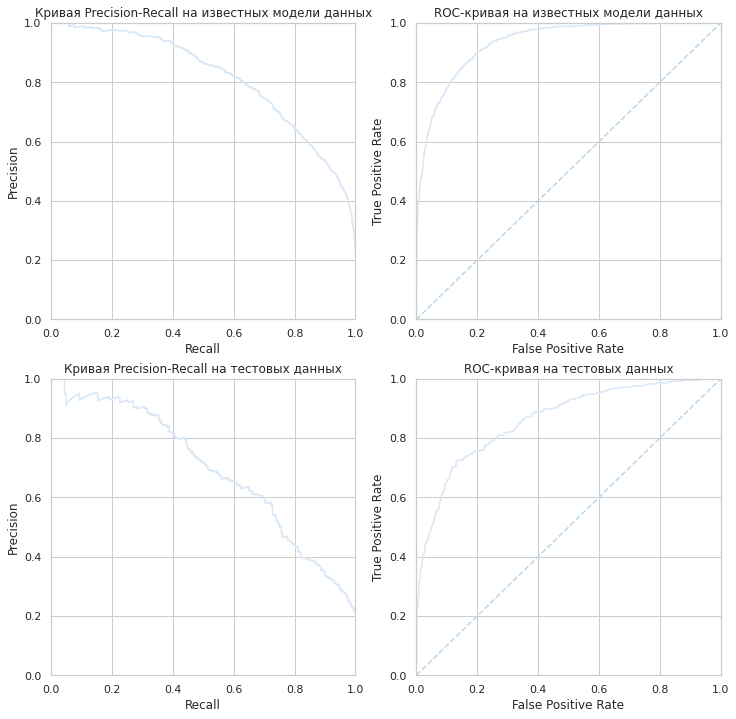

In [54]:
# инициализация оптимальной модели для распознания оттока
model = RandomForestClassifier(n_estimators=70,
                               max_depth=9,
                               min_samples_leaf=3, 
                               min_samples_split=2, 
                               class_weight='balanced')

# вызов функции для оценки модели
model_reserch_overfitting(model)

Итак, на тестовых данных модель решила поставленную задачу, метрики F1 и AUC-ROC составили 0,6311 и 0,8652 соответсвенно.

Однако, оценив предективные способности модели на известных модели данных, автор выявил некоторое переобучение - метрики оказались значительн выше: F1 0,7222, AUC-ROC 0,9347.

Вопрос переобучения решается путем "упрощения" модели: исключение ряда признаков для подгонки, фичиинжинерией - созданием дополнительных признаков, которые сильнее влияют на цлевую переменную. Данных аспект выходит за рамки настоящего исследования.

## Вывод

В ходе настоящего иследования требовалось оценить влияние дисбаланса целовего на качество моделей класификации.

В качестве метрик-оценок качества моделей применялись F1 - гармоническое среднее между полнотой и точности и AUC-ROC - площать под кривой соотношения полноты модели и доли ложных срабатываний.

Анализировались наблюдений, связанные с оттоком клиентов из банка.

В ходе подготовки матрицы для подгонки моделей, данные были перекодированы, стандартизированы. Отобраны признаки для обучения и распознания.

В эксперименте участие принимали три модели: логистической регрессии, решающего дерева и случайного леса. Каждая модель были оценена с дефолными и подобранными гипрепараметрами, с выборками со взвешиванием классов, увеличенными и уменьшенными сбалансирвоанными выборками.

Автором эксперементальным путем доказано, что линенйные модели наиболее чувствительны к дисбалансу выборки, а модели, оснванные на деревьях решений практически робастны к диспропорциям.

При этом для линейных моделей метрики оставались в реферетных значениях независимо от вида балансировки, в то время, как модели, основанные на деревьях показали лучший результат при взвешивании классов.

Оптимальной молелью автор признал случайный лес. Модель прошла проверку на адекватность и решила поставленную задачу, установив метрику F1 на уровне 0,6311.

Дополнительно стоит отметить, что кроме вышеобозначенных методов решении проблемы дисбаланса, возможно применения алгоритма, который генерирует определенное количество похожих примеров класса с меньшим количеством данных, но при этом не дублирует данные в этом классе.

Такой алгоритм балансировки классов называется SMOTE (Synthetic Minority Oversampling Technique).

Экпериметально доказана связь метрик F1 и AUC-ROC по показателю "полноты" (Recall - для F1 и True positive rate - для AUC-ROC): с увеличем полноты охвата точность (Precision для F1) будет снижаться, а количество ложных срабатываний (False positive для AUC-ROC) будет расти. При этом, при оптимальном определении трешхолда (отсечки срока модели для отнесения целевой переменной к определнному классу) с улучшением F1, площадь под кривой ROC будет увеличиваться и стремиться к единице за счет тяготения графика ROC к левому верхнему углу системы координат.

Таким образом, F1 показывает более "правдивую" картину при дисбалансе классов. AUC-ROC слабо чувствителен к дисбалансу. Поэтому важно сравнить параметры метрик у конкретной модели при дисбалансе и после устранения дисбаланса. Яриким примером в настоящим ииследовани служит логистическая регрессия - F1 меняется сильно при устранении дисбаланса, а AUC-ROC стоит на месте.

<!-- portfolio-summary -->
## Краткий итог кейса

Кейс показывает, как дисбаланс классов и выбор метрик влияют на результат задачи оттока клиентов. Отдельно сравнивается базовый подход и подход с балансировкой, чтобы наглядно показать, почему accuracy сама по себе может вводить в заблуждение.
